In [2]:
import vireoSNP
import numpy as np
from scipy import sparse
from scipy.io import mmread
import matplotlib.pyplot as plt

print(vireoSNP.__version__)

0.5.9


In [4]:
# read in the variant matrices
AD = mmread("../../../results/standalone/mquad/TNBC1/passed_ad.mtx").tocsc()
DP = mmread("../../../results/standalone/mquad/TNBC1/passed_dp.mtx").tocsc()

In [6]:
# identify the clones
from vireoSNP import BinomMixtureVB
_model = BinomMixtureVB(n_var=AD.shape[0], n_cell=AD.shape[1], n_donor=3)
_model.fit(AD, DP, min_iter=30, n_init=50)
print(_model.ELBO_iters[-1])

-1920.1822626998164


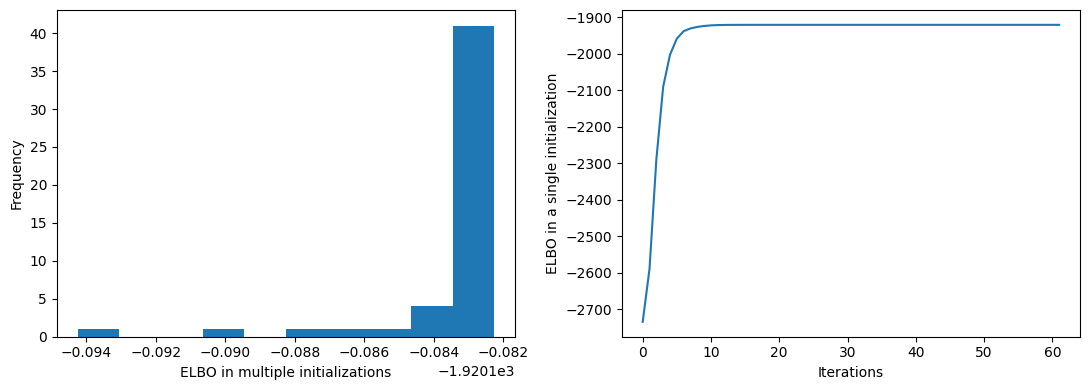

In [7]:
# check the model fitting
fig = plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.hist(_model.ELBO_inits)
plt.ylabel("Frequency")
plt.xlabel("ELBO in multiple initializations")

plt.subplot(1, 2, 2)
plt.plot(_model.ELBO_iters)
plt.xlabel("Iterations")
plt.ylabel("ELBO in a single initialization")

plt.tight_layout()
plt.show()

In [8]:
# In mitochondrial, allele frequency is highly informative between 0.01 to 0.1, 
# so we rescale the colour to give more spectrum for this region.
# You can design/choose your own colors from here: 
# https://matplotlib.org/stable/tutorials/colors/colormaps.html

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

raw_col = cm.get_cmap('pink_r', 200)
new_col = np.vstack((raw_col(np.linspace(0, 0.7, 10)),
                     raw_col(np.linspace(0.7, 1, 90))))
segpink = ListedColormap(new_col, name='segpink')

/tmp/ipykernel_882218/1441482904.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  raw_col = cm.get_cmap('pink_r', 200)


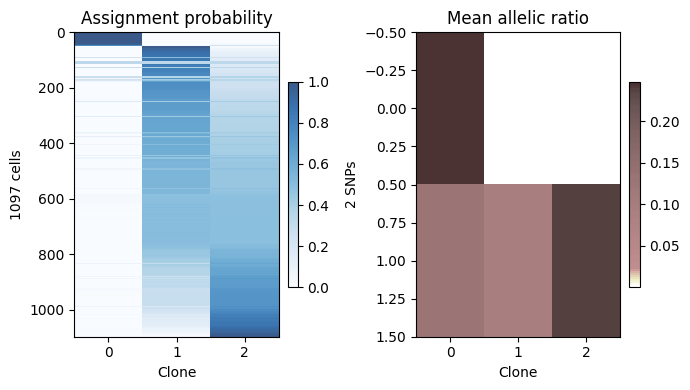

In [9]:
from vireoSNP.plot import heat_matrix

fig = plt.figure(figsize=(7, 4), dpi=100)
plt.subplot(1, 2, 1)
im = heat_matrix(_model.ID_prob, cmap="Blues", alpha=0.8,
                 display_value=False, row_sort=True)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Assignment probability")
plt.xlabel("Clone")
plt.ylabel("%d cells" %(_model.n_cell))
plt.xticks(range(_model.n_donor))


plt.subplot(1, 2, 2)
im = heat_matrix(_model.beta_mu, cmap=segpink, alpha=0.8, 
                 display_value=False, row_sort=True)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Mean allelic ratio")
plt.xlabel("Clone")
plt.ylabel("%d SNPs" %(_model.n_var))
plt.xticks(range(_model.n_donor))

plt.tight_layout()
plt.show()
# plt.savefig("you_favorate_path with png or pdf")

In [10]:
# Diagnosis
# Double check if global optima is found
# We are using multiple initializations via n_init and choose the one with highest ELBO. However, this doesn't guarantee to be the global optima. To double check it, we can run the same scripts multiple time (without fixed random seed), and check if the same (best) ELBO is found.

# If yes, it is likely to be the global optima, otherwise, we need increase n_init, e.g., 300 for more search.

n_init = 50
for i in range(3):
    _model = BinomMixtureVB(n_var=AD.shape[0], n_cell=AD.shape[1], n_donor=3)
    _model.fit(AD, DP, min_iter=30, n_init=n_init)
    print("rerun %d:" %i, _model.ELBO_iters[-1])

rerun 0: -1920.1822626998428
rerun 1: -1920.1822626999733
rerun 2: -1920.1822626998378


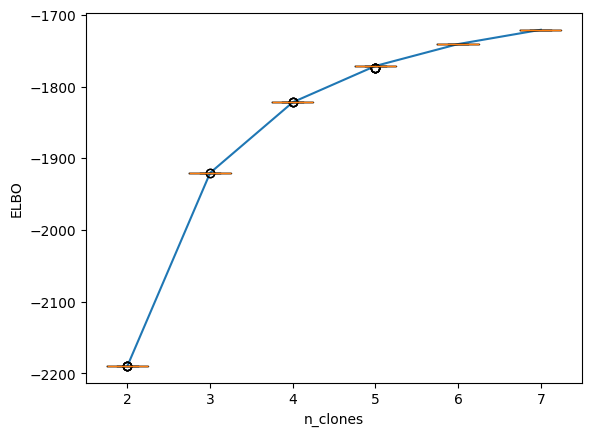

In [12]:
# Identify the suitable number of clones
# It is generally difficult to identify the number of clones, which is a balance between subclone resolution and analysis reliability. More clones maybe preferred, but there could be higher risk that the subclones are not genuine but rather technical noise.

# Here, we could use ELBO for different number of clones as an indictor for model selection. However, this is still imperfect. One empirical suggestion is to choose the n_clones when ELBO stops increasing dramatically, for example in the case below, we will pick 3 clones.

n_init = 50
n_clone_list = np.arange(2, 8)

_ELBO_mat = []
for k in n_clone_list:
    _model = BinomMixtureVB(n_var=AD.shape[0], n_cell=AD.shape[1], n_donor=k)
    _model.fit(AD, DP, min_iter=30, n_init=n_init)
    _ELBO_mat.append(_model.ELBO_inits)
plt.plot(np.arange(1, len(n_clone_list)+1), np.max(_ELBO_mat, axis=1))
plt.boxplot(_ELBO_mat)
plt.xticks(np.arange(1, len(n_clone_list)+1), n_clone_list)
plt.ylabel("ELBO")
plt.xlabel("n_clones")
plt.show()

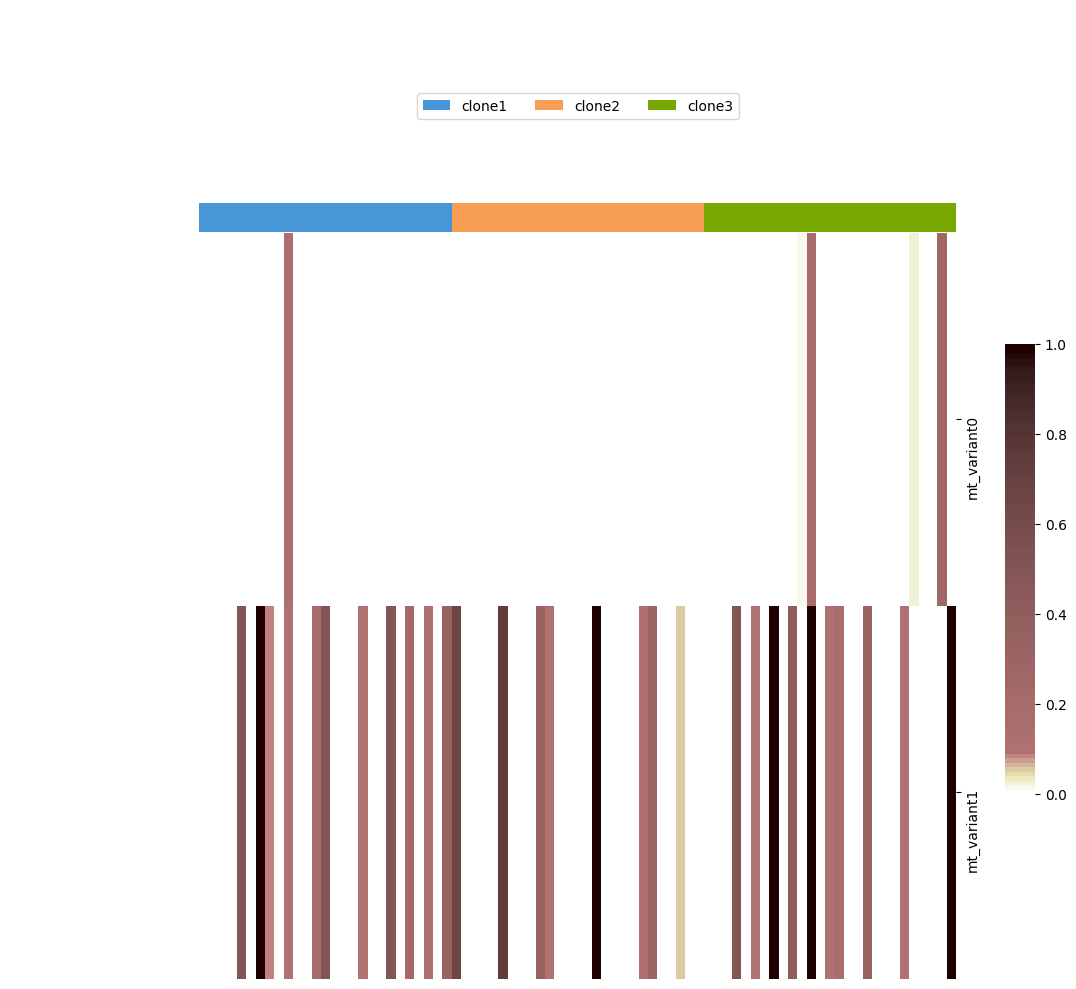

In [14]:
# Visualization
# If you want to visualise the raw allele frequency with annotation of cells, you may consider seaborn.clustermap. We also wrap this function here as vireoSNP.plot.anno_heat for quick use.
mtSNP_ids = ['mt_variant%d' %x for x in range(AD.shape[0])]
cell_label = np.array(['clone1'] * 27 + ['clone2'] * 27 + ['clone3'] * 27)
id_uniq = ['clone1', 'clone2', 'clone3']
vireoSNP.plot.anno_heat(AD/DP, col_anno=cell_label, col_order_ids=id_uniq, 
                        cmap=segpink, yticklabels=mtSNP_ids)

In [15]:
cell_label

array(['clone1', 'clone1', 'clone1', 'clone1', 'clone1', 'clone1',
       'clone1', 'clone1', 'clone1', 'clone1', 'clone1', 'clone1',
       'clone1', 'clone1', 'clone1', 'clone1', 'clone1', 'clone1',
       'clone1', 'clone1', 'clone1', 'clone1', 'clone1', 'clone1',
       'clone1', 'clone1', 'clone1', 'clone2', 'clone2', 'clone2',
       'clone2', 'clone2', 'clone2', 'clone2', 'clone2', 'clone2',
       'clone2', 'clone2', 'clone2', 'clone2', 'clone2', 'clone2',
       'clone2', 'clone2', 'clone2', 'clone2', 'clone2', 'clone2',
       'clone2', 'clone2', 'clone2', 'clone2', 'clone2', 'clone2',
       'clone3', 'clone3', 'clone3', 'clone3', 'clone3', 'clone3',
       'clone3', 'clone3', 'clone3', 'clone3', 'clone3', 'clone3',
       'clone3', 'clone3', 'clone3', 'clone3', 'clone3', 'clone3',
       'clone3', 'clone3', 'clone3', 'clone3', 'clone3', 'clone3',
       'clone3', 'clone3', 'clone3'], dtype='<U6')